<a href="https://colab.research.google.com/github/ssritthigasri2005-cmyk/dna-sequence-analyzer/blob/main/dna_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.6 MB/s eta 0:00:00


In [2]:
# Your first bioinformatics code!
from Bio.Seq import Seq

# Define a DNA sequence
dna = Seq("ATGCTAGCTAGCTAGCTAGC")

# Basic analysis
print("DNA Sequence:    ", dna)
print("Length:          ", len(dna))
print("GC Content %:    ", round((dna.count("G") + dna.count("C")) / len(dna) * 100, 2))
print("Complement:      ", dna.complement())
print("Reverse Complement:", dna.reverse_complement())
print("mRNA (Transcription):", dna.transcribe())
print("Protein (Translation):", dna.transcribe().translate())

DNA Sequence:     ATGCTAGCTAGCTAGCTAGC
Length:           20
GC Content %:     50.0
Complement:       TACGATCGATCGATCGATCG
Reverse Complement: GCTAGCTAGCTAGCTAGCAT
mRNA (Transcription): AUGCUAGCUAGCUAGCUAGC
Protein (Translation): MLAS*L


/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [3]:
# ===== DNA SEQUENCE ANALYZER =====
from Bio.Seq import Seq
import matplotlib.pyplot as plt

# ---- INPUT YOUR DNA SEQUENCE ----
dna = Seq("ATGCTAGCTAGCTAGCTAGCTAGCTAGCTAGC")

print("=" * 40)
print("       DNA SEQUENCE ANALYZER")
print("=" * 40)

# 1. Basic Info
print(f"\n🧬 DNA Sequence   : {dna}")
print(f"📏 Length          : {len(dna)} bases")

# 2. GC Content
gc = round((dna.count("G") + dna.count("C")) / len(dna) * 100, 2)
print(f"🔬 GC Content      : {gc}%")

# 3. Complement & Reverse Complement
print(f"🔁 Complement      : {dna.complement()}")
print(f"↩️  Reverse Comp   : {dna.reverse_complement()}")

# 4. Transcription (DNA → mRNA)
mrna = dna.transcribe()
print(f"\n📜 mRNA            : {mrna}")

# 5. Translation (mRNA → Protein)
protein = mrna.translate()
print(f"🧪 Protein         : {protein}")

       DNA SEQUENCE ANALYZER

🧬 DNA Sequence   : ATGCTAGCTAGCTAGCTAGCTAGCTAGCTAGC
📏 Length          : 32 bases
🔬 GC Content      : 50.0%
🔁 Complement      : TACGATCGATCGATCGATCGATCGATCGATCG
↩️  Reverse Comp   : GCTAGCTAGCTAGCTAGCTAGCTAGCTAGCAT

📜 mRNA            : AUGCUAGCUAGCUAGCUAGCUAGCUAGCUAGC
🧪 Protein         : MLAS*LAS*L


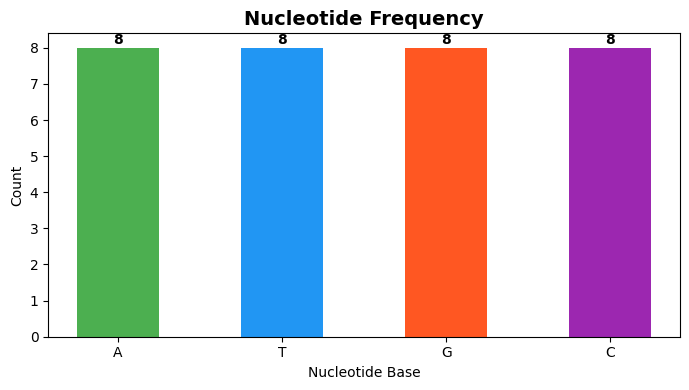

In [4]:
# ===== NUCLEOTIDE FREQUENCY CHART =====

# Count each base
bases = ["A", "T", "G", "C"]
counts = [dna.count(b) for b in bases]
colors = ["#4CAF50", "#2196F3", "#FF5722", "#9C27B0"]

# Plot
plt.figure(figsize=(7, 4))
plt.bar(bases, counts, color=colors, width=0.5)
plt.title("Nucleotide Frequency", fontsize=14, fontweight="bold")
plt.xlabel("Nucleotide Base")
plt.ylabel("Count")
for i, count in enumerate(counts):
    plt.text(i, count + 0.1, str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
# ===== ORF FINDER =====
print("=" * 40)
print("       OPEN READING FRAMES (ORFs)")
print("=" * 40)

dna_str = str(dna)
start_codon = "ATG"
stop_codons = ["TAA", "TAG", "TGA"]
orfs = []

for i in range(len(dna_str) - 2):
    if dna_str[i:i+3] == start_codon:
        for j in range(i, len(dna_str) - 2, 3):
            codon = dna_str[j:j+3]
            if codon in stop_codons:
                orf = dna_str[i:j+3]
                if len(orf) > 6:
                    orfs.append(orf)
                break

if orfs:
    for idx, orf in enumerate(orfs):
        print(f"\n✅ ORF {idx+1}: {orf}")
        print(f"   Length : {len(orf)} bases")
else:
    print("\n❌ No ORFs found in this sequence")

       OPEN READING FRAMES (ORFs)

✅ ORF 1: ATGCTAGCTAGCTAG
   Length : 15 bases


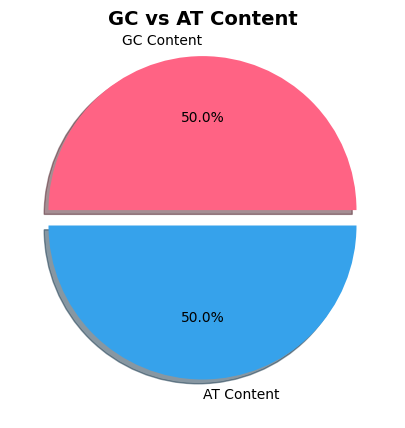

In [6]:
# ===== GC vs AT PIE CHART =====

gc_count = dna.count("G") + dna.count("C")
at_count = dna.count("A") + dna.count("T")

labels = ["GC Content", "AT Content"]
sizes = [gc_count, at_count]
colors = ["#FF6384", "#36A2EB"]
explode = (0.1, 0)

plt.figure(figsize=(6, 5))
plt.pie(sizes, explode=explode, labels=labels,
        colors=colors, autopct="%1.1f%%", shadow=True)
plt.title("GC vs AT Content", fontsize=14, fontweight="bold")
plt.show()

In [7]:
# ===== FINAL SUMMARY REPORT =====

print("=" * 40)
print("        FINAL ANALYSIS REPORT")
print("=" * 40)
print(f"  Sequence Length   : {len(dna)} bp")
print(f"  GC Content        : {gc}%")
print(f"  AT Content        : {round(100 - gc, 2)}%")
print(f"  Total ORFs Found  : {len(orfs)}")
print(f"  mRNA              : {mrna}")
print(f"  Protein           : {protein}")
print("=" * 40)
print("✅ Analysis Complete!")

        FINAL ANALYSIS REPORT
  Sequence Length   : 32 bp
  GC Content        : 50.0%
  AT Content        : 50.0%
  Total ORFs Found  : 1
  mRNA              : AUGCUAGCUAGCUAGCUAGCUAGCUAGCUAGC
  Protein           : MLAS*LAS*L
✅ Analysis Complete!
